# Stage 1 — rate-matrix inspection

Load a binned rate matrix produced by `src/01_extraction.py` and sanity-check
the **binned** representation (notebook `00` checks the raw spikes; this one
checks what extraction actually wrote). CA1 and PFC are kept in separate files.

Checks:
1. Contents / shapes / metadata of the `.npz`
2. Rate-matrix heatmap (units x time), epoch boundaries marked
3. Per-unit mean rate and sparsity, by condition
4. Behavior columns aligned to bins (trajectory per condition, speed)
5. Novel-vs-familiar mean-rate comparison (a first look at "trivial rate change")

If a matrix is missing, run `pixi run python src/01_extraction.py` first.


## Setup

In [5]:
import sys
import pathlib

for _p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
    if (_p / "src" / "config.py").exists():
        sys.path.insert(0, str(_p / "src"))
        break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config import DATA_PROCESSED, BIN_SIZE_S

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["figure.dpi"] = 100

## Pick a rate matrix
List what stage 1 has written and load one file.

In [6]:
available = sorted(DATA_PROCESSED.glob("rates_*.npz"))
for i, f in enumerate(available):
    print(i, f.name)
assert available, "no rate matrices found — run: pixi run python src/01_extraction.py"

RATE_FILE = available[0]   # change index to inspect another subject/region
d = np.load(RATE_FILE, allow_pickle=False)
subject = str(d["subject"]); region = str(d["region"]); dt = float(d["bin_size_s"])
print(f"\nloaded {RATE_FILE.name}: subject={subject} region={region} bin={dt*1000:.0f}ms")

0 rates_JDS-NFN-AM2_CA1_1000ms.npz
1 rates_JDS-NFN-AM2_CA1_50ms.npz
2 rates_JDS-NFN-AM2_PFC_1000ms.npz
3 rates_JDS-NFN-AM2_PFC_50ms.npz
4 rates_JDS-NFN-JS17_CA1_1000ms.npz
5 rates_JDS-NFN-JS17_CA1_50ms.npz
6 rates_JDS-NFN-JS17_PFC_1000ms.npz
7 rates_JDS-NFN-JS17_PFC_50ms.npz
8 rates_JDS-NFN-JS21_CA1_1000ms.npz
9 rates_JDS-NFN-JS21_CA1_50ms.npz
10 rates_JDS-NFN-JS21_PFC_1000ms.npz
11 rates_JDS-NFN-JS21_PFC_50ms.npz
12 rates_JDS-NFN-JS34_CA1_1000ms.npz
13 rates_JDS-NFN-JS34_CA1_50ms.npz
14 rates_JDS-NFN-JS34_PFC_1000ms.npz
15 rates_JDS-NFN-JS34_PFC_50ms.npz
16 rates_JDS-NFN-ZT2_CA1_1000ms.npz
17 rates_JDS-NFN-ZT2_CA1_50ms.npz
18 rates_JDS-NFN-ZT2_PFC_1000ms.npz
19 rates_JDS-NFN-ZT2_PFC_50ms.npz

loaded rates_JDS-NFN-AM2_CA1_1000ms.npz: subject=JDS-NFN-AM2 region=CA1 bin=1000ms


## 1. Contents and metadata

In [7]:
rates = d["rates"]; time = d["time"]; epoch = d["epoch"]; condition = d["condition"]
T, n_units = rates.shape
print("keys      :", list(d.keys()))
print("rates     :", rates.shape, rates.dtype, "(sqrt spike counts / bin)")
print("time span :", f"{time[0]:.1f}-{time[-1]:.1f} s")
print("units kept:", n_units, "ids", d["unit_ids"][:8], "...")

pd.DataFrame({"epoch": epoch, "condition": condition}).value_counts().sort_index()

keys      : ['rates', 'time', 'position', 'velocity', 'epoch', 'condition', 'unit_ids', 'subject', 'region', 'bin_size_s', 'source']
rates     : (2722, 32) float32 (sqrt spike counts / bin)
time span : 2323.0-11690.3 s
units kept: 32 ids [14 15 16 17 18 19 20 21] ...


epoch  condition
0      novel        878
1      familiar     899
2      novel        945
Name: count, dtype: int64

## 2. Rate-matrix heatmap

Units x time. Epoch boundaries are drawn where the epoch index changes (there
are large time gaps between epochs, so the x-axis is bin index, not seconds).

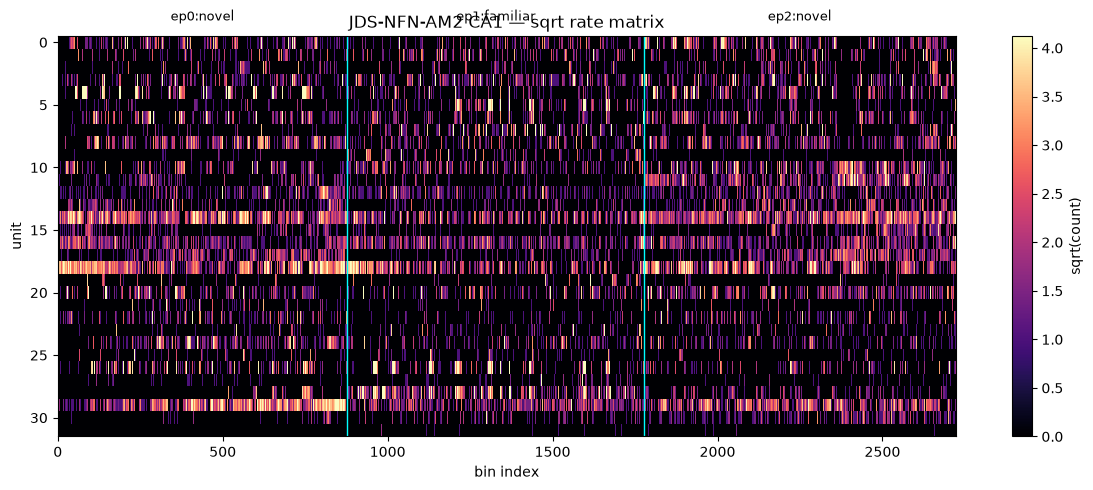

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(rates.T, aspect="auto", interpolation="nearest",
               cmap="magma", vmax=np.percentile(rates, 99))
bounds = np.flatnonzero(np.diff(epoch)) + 1
for b in bounds:
    ax.axvline(b, color="cyan", lw=1)
# label each epoch block with its condition at the block center
edges = np.concatenate([[0], bounds, [T]])
for k in range(len(edges) - 1):
    c = (edges[k] + edges[k + 1]) / 2
    ax.text(c, -1.5, f"ep{epoch[edges[k]]}:{condition[edges[k]]}",
            ha="center", va="bottom", color="k", fontsize=9)
ax.set_xlabel("bin index"); ax.set_ylabel("unit")
ax.set_title(f"{subject} {region} — sqrt rate matrix")
fig.colorbar(im, ax=ax, label="sqrt(count)")
plt.tight_layout()

## 3. Per-unit mean rate and sparsity

median rate 1.22 Hz, median sparsity 69.20%


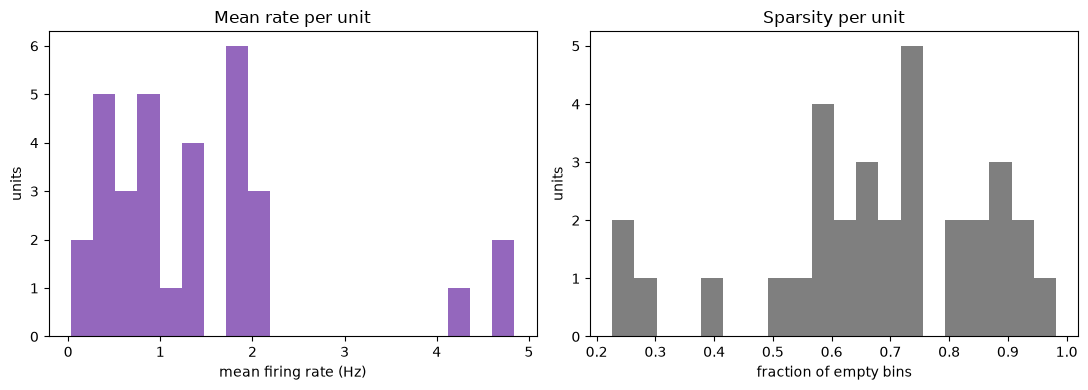

In [9]:
counts = rates.astype(np.float64) ** 2      # undo sqrt -> spike counts
mean_hz = counts.sum(0) / (T * dt)
sparsity = (counts == 0).mean(0)            # fraction of empty bins per unit

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(mean_hz, bins=20, color="tab:purple")
axes[0].set_xlabel("mean firing rate (Hz)"); axes[0].set_ylabel("units")
axes[0].set_title("Mean rate per unit")
axes[1].hist(sparsity, bins=20, color="tab:gray")
axes[1].set_xlabel("fraction of empty bins"); axes[1].set_ylabel("units")
axes[1].set_title("Sparsity per unit")
plt.tight_layout()
print(f"median rate {np.median(mean_hz):.2f} Hz, median sparsity {np.median(sparsity):.2%}")

## 4. Behavior aligned to bins
Trajectory per condition + speed; confirms behavior columns line up with bins.

speed nan frac: 0.0 | range: 0.0 - 48.41806 cm/s


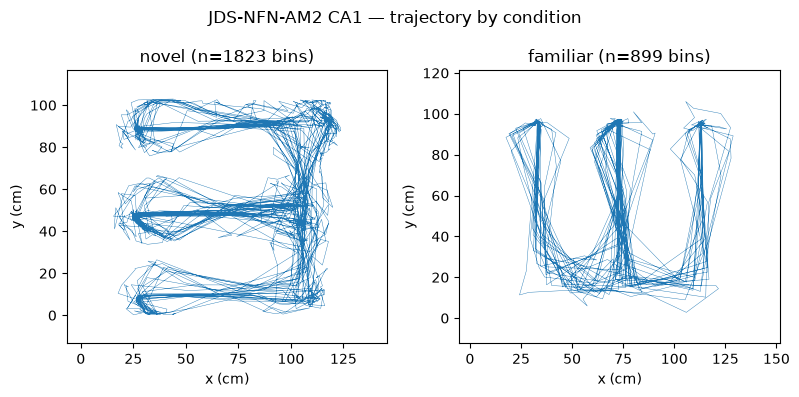

In [10]:
pos = d["position"]; vel = d["velocity"]
conds_unique = list(dict.fromkeys(condition.tolist()))
fig, axes = plt.subplots(1, len(conds_unique), figsize=(4 * len(conds_unique), 4), squeeze=False)
for k, c in enumerate(conds_unique):
    m = condition == c
    ax = axes[0, k]
    ax.plot(pos[m, 0], pos[m, 1], lw=0.3)
    ax.set_title(f"{c} (n={m.sum()} bins)")
    ax.set_xlabel("x (cm)"); ax.set_ylabel("y (cm)")
    ax.set_aspect("equal", adjustable="datalim")
fig.suptitle(f"{subject} {region} — trajectory by condition")
plt.tight_layout()

print("speed nan frac:", np.isnan(vel).mean(),
      "| range:", np.nanmin(vel), "-", np.nanmax(vel), "cm/s")

## 5. Novel vs. familiar mean rate

A first look at the open question: how much of the novel/familiar difference is
a trivial firing-rate change vs. genuine geometric reshaping (later stages)?
Here we only compare per-unit mean rates between conditions.

condition,familiar,novel
count,32.000000,32.000000
mean,1.203629,1.551546
std,1.021763,1.488854
min,0.047831,0.019199
25%,0.390712,0.427729
50%,0.956618,1.253428
75%,1.914905,2.023176
max,3.838710,5.695557


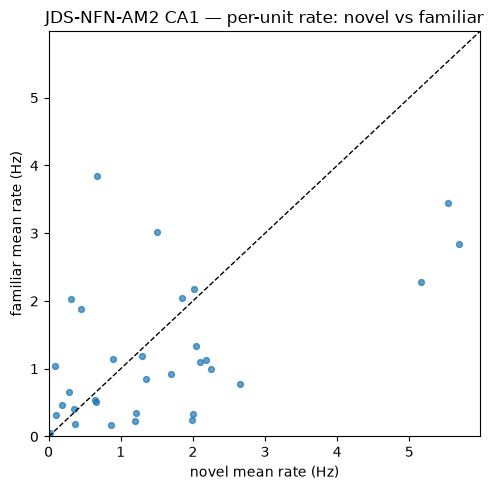

In [11]:
df = pd.DataFrame(counts, columns=[f"u{u}" for u in d["unit_ids"]])
df["condition"] = condition
per_cond_hz = df.groupby("condition").sum().T / (
    pd.Series(condition).value_counts() * dt)
per_cond_hz = per_cond_hz.dropna(axis=1)

if {"novel", "familiar"}.issubset(per_cond_hz.columns):
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(per_cond_hz["novel"], per_cond_hz["familiar"], s=18, alpha=0.7)
    lim = [0, per_cond_hz[["novel", "familiar"]].values.max() * 1.05]
    ax.plot(lim, lim, "k--", lw=1)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel("novel mean rate (Hz)"); ax.set_ylabel("familiar mean rate (Hz)")
    ax.set_title(f"{subject} {region} — per-unit rate: novel vs familiar")
    plt.tight_layout()
per_cond_hz.describe()

---
**Next:** with rate matrices validated, stage 2 (`src/02_baseline_linear.py`)
can run PCA / GPFA / dPCA on these matrices per region and condition.